# Phân tích dữ liệu LOC 5-Core JSON

Notebook này dùng để kiểm tra dữ liệu sau khi convert từ CSV sang JSON 5-core.

Mục tiêu chính:

- Kiểm tra phân phối nhãn `LOC_Level`.
- Kiểm tra dữ liệu có bị lệch lớp không.
- Kiểm tra các cụm nhãn có tách biệt rõ ràng không.
- Trực quan hóa dữ liệu bằng PCA và t-SNE.
- Kiểm tra tương quan feature.
- Kiểm tra feature nào ảnh hưởng mạnh đến nhãn.
- Chỉ ra các vấn đề cần ghi vào báo cáo.

Lưu ý quan trọng: `LOC_Level` là nhãn synthetic rule-based, không phải nhãn LOC lâm sàng chính thức.


In [1]:
# 1. Import libraries

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, balanced_accuracy_score, f1_score

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


## 2. Tìm file dữ liệu

Notebook sẽ tự tìm file JSON ở một số vị trí thường gặp:

- `train/heart_disease_loc_5core.json`
- `heart_disease_loc_5core.json`
- `Train_linh/train/heart_disease_loc_5core.json`

Nếu chưa có file JSON, cần chạy trước:

```powershell
python convert_csv_to_5core_json.py
```


In [2]:
# 2. Locate JSON file

def find_file(filename, search_roots=None):
    if search_roots is None:
        search_roots = [
            Path.cwd(),
            Path.cwd() / "train",
            Path.cwd() / "Train_linh",
            Path.cwd() / "Train_linh" / "train",
            Path.cwd().parent,
            Path.cwd().parent / "train",
        ]

    for root in search_roots:
        path = root / filename
        if path.exists():
            return path

    # Last fallback: recursive search, limited to current project folder
    for path in Path.cwd().rglob(filename):
        return path

    raise FileNotFoundError(
        f"Không tìm thấy {filename}. Hãy chạy convert_csv_to_5core_json.py trước "
        f"hoặc đặt file vào thư mục train/."
    )

JSON_PATH = find_file("heart_disease_loc_5core.json")
print("JSON path:", JSON_PATH)


JSON path: d:\MockProject\MockProject_062026_NhomAI\Train_linh\train\heart_disease_loc_5core.json


In [3]:
# 3. Load and flatten JSON

def flatten_record(record):
    out = {}
    cores = record.get("5_cores", {})

    for core_name, features in cores.items():
        if isinstance(features, dict):
            for feature_name, value in features.items():
                out[f"{core_name}__{feature_name}"] = value

    # Keep these only for analysis, not for model input
    out["care_score"] = record.get("care_score")
    out["LOC_Level"] = record.get("LOC_Level")
    return out

with open(JSON_PATH, "r", encoding="utf-8") as f:
    records = json.load(f)

df = pd.DataFrame([flatten_record(r) for r in records])

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["LOC_Level"]).reset_index(drop=True)
df["LOC_Level"] = df["LOC_Level"].astype(int)

print("Shape:", df.shape)
display(df.head())


Shape: (10459, 28)


,ADLs_IADLs__Age,ADLs_IADLs__DiffWalk,ADLs_IADLs__PhysActivity,ADLs_IADLs__PhysHlth,Cognitive_Neurological_Status__Stroke,Cognitive_Neurological_Status__MentHlth,Clinical_Risk_Assessments__HeartDiseaseorAttack,Clinical_Risk_Assessments__HighBP,Clinical_Risk_Assessments__HighChol,Clinical_Risk_Assessments__CholCheck,...,Mood_Behavioral_Health__Fruits,Mood_Behavioral_Health__Veggies,Financial_Legal_General_Status__Age,Financial_Legal_General_Status__Sex,Financial_Legal_General_Status__Education,Financial_Legal_General_Status__Income,Financial_Legal_General_Status__NoDocbcCost,Financial_Legal_General_Status__AnyHealthcare,care_score,LOC_Level
0,9.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,...,1.0,1.0,9.0,1.0,6.0,8.0,0.0,1.0,11,3
1,11.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,11.0,0.0,5.0,3.0,0.0,1.0,12,3
2,13.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,13.0,0.0,4.0,2.0,0.0,1.0,6,2
3,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,10.0,1.0,4.0,6.0,0.0,1.0,5,2
4,11.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,11.0,0.0,6.0,6.0,0.0,1.0,6,2


In [4]:
# 4. Basic information

print("Rows:", len(df))
print("Columns:", df.shape[1])
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(20))

print("\nNumeric summary:")
display(df.describe().T)


Rows: 10459
Columns: 28

Missing values:


ADLs_IADLs__Age                                    0
ADLs_IADLs__DiffWalk                               0
ADLs_IADLs__PhysActivity                           0
ADLs_IADLs__PhysHlth                               0
Cognitive_Neurological_Status__Stroke              0
Cognitive_Neurological_Status__MentHlth            0
Clinical_Risk_Assessments__HeartDiseaseorAttack    0
Clinical_Risk_Assessments__HighBP                  0
Clinical_Risk_Assessments__HighChol                0
Clinical_Risk_Assessments__CholCheck               0
Clinical_Risk_Assessments__Diabetes                0
Clinical_Risk_Assessments__BMI                     0
Clinical_Risk_Assessments__GenHlth                 0
Clinical_Risk_Assessments__PhysHlth                0
Clinical_Risk_Assessments__AnyHealthcare           0
Mood_Behavioral_Health__MentHlth                   0
Mood_Behavioral_Health__Smoker                     0
Mood_Behavioral_Health__HvyAlcoholConsump          0
Mood_Behavioral_Health__Fruits                


Numeric summary:


,count,mean,std,min,25%,50%,75%,max
ADLs_IADLs__Age,10459.0,10.699206,1.445964,9.0,9.0,10.0,12.0,13.0
ADLs_IADLs__DiffWalk,10459.0,0.521656,0.499555,0.0,0.0,1.0,1.0,1.0
ADLs_IADLs__PhysActivity,10459.0,0.281480,0.449743,0.0,0.0,0.0,1.0,1.0
ADLs_IADLs__PhysHlth,10459.0,7.784970,11.260130,0.0,0.0,1.0,14.0,30.0
Cognitive_Neurological_Status__Stroke,10459.0,0.080409,0.271939,0.0,0.0,0.0,0.0,1.0
Cognitive_Neurological_Status__MentHlth,10459.0,3.627976,8.086153,0.0,0.0,0.0,2.0,30.0
Clinical_Risk_Assessments__HeartDiseaseorAttack,10459.0,0.185199,0.388478,0.0,0.0,0.0,0.0,1.0
Clinical_Risk_Assessments__HighBP,10459.0,0.676929,0.467672,0.0,0.0,1.0,1.0,1.0
Clinical_Risk_Assessments__HighChol,10459.0,0.592791,0.491338,0.0,0.0,1.0,1.0,1.0
Clinical_Risk_Assessments__CholCheck,10459.0,0.982503,0.131120,0.0,1.0,1.0,1.0,1.0


In [9]:
# 8. Prepare X and y

feature_cols = [c for c in df.columns if c not in ["LOC_Level", "care_score"]]
X = df[feature_cols].copy()
y = df["LOC_Level"].copy()

X = X.fillna(X.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Number of features:", len(feature_cols))
print("Features:")
for c in feature_cols:
    print("-", c)


Number of features: 26
Features:
- ADLs_IADLs__Age
- ADLs_IADLs__DiffWalk
- ADLs_IADLs__PhysActivity
- ADLs_IADLs__PhysHlth
- Cognitive_Neurological_Status__Stroke
- Cognitive_Neurological_Status__MentHlth
- Clinical_Risk_Assessments__HeartDiseaseorAttack
- Clinical_Risk_Assessments__HighBP
- Clinical_Risk_Assessments__HighChol
- Clinical_Risk_Assessments__CholCheck
- Clinical_Risk_Assessments__Diabetes
- Clinical_Risk_Assessments__BMI
- Clinical_Risk_Assessments__GenHlth
- Clinical_Risk_Assessments__PhysHlth
- Clinical_Risk_Assessments__AnyHealthcare
- Mood_Behavioral_Health__MentHlth
- Mood_Behavioral_Health__Smoker
- Mood_Behavioral_Health__HvyAlcoholConsump
- Mood_Behavioral_Health__Fruits
- Mood_Behavioral_Health__Veggies
- Financial_Legal_General_Status__Age
- Financial_Legal_General_Status__Sex
- Financial_Legal_General_Status__Education
- Financial_Legal_General_Status__Income
- Financial_Legal_General_Status__NoDocbcCost
- Financial_Legal_General_Status__AnyHealthcare


Explained variance ratio: [0.14007395 0.09362917]
Total explained variance: 0.23370312256547138


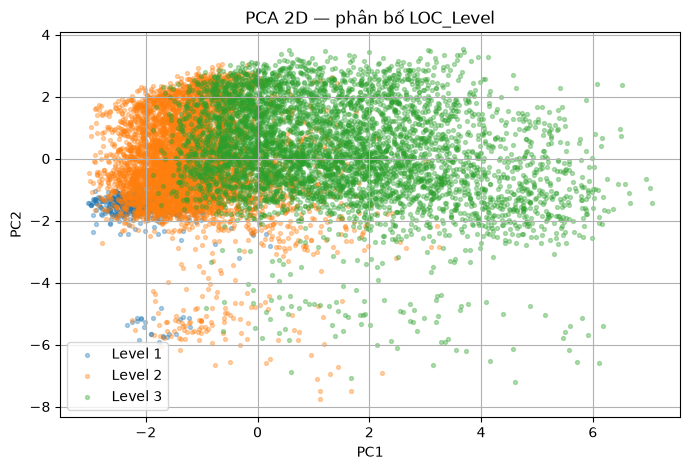

In [10]:
# 9. PCA 2D visualization

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "LOC_Level": y.values
})

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

plt.figure()
for level in sorted(pca_df["LOC_Level"].unique()):
    part = pca_df[pca_df["LOC_Level"] == level]
    plt.scatter(part["PC1"], part["PC2"], s=8, alpha=0.35, label=f"Level {level}")
plt.title("PCA 2D — phân bố LOC_Level")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()


## 8. Đo độ tách cụm bằng metric

Các chỉ số này dùng để đánh giá cụm nhãn trên feature space.

- **Silhouette Score**: càng gần 1 càng tách tốt, gần 0 là chồng lấn.
- **Davies-Bouldin Score**: càng thấp càng tốt.
- **Calinski-Harabasz Score**: càng cao càng tốt.

Lưu ý: đây không phải metric phân loại, chỉ là metric để xem nhãn có tạo thành cụm rõ không.


In [11]:
# 10. Cluster separability metrics

# Use sample to avoid slow computation
sample_size = min(8000, len(df))
sample_idx = df.sample(n=sample_size, random_state=RANDOM_STATE).index

X_sample = X_scaled[sample_idx]
y_sample = y.iloc[sample_idx]

sil = silhouette_score(X_sample, y_sample)
db = davies_bouldin_score(X_sample, y_sample)
ch = calinski_harabasz_score(X_sample, y_sample)

metrics_table = pd.DataFrame({
    "metric": ["Silhouette Score", "Davies-Bouldin Score", "Calinski-Harabasz Score"],
    "value": [sil, db, ch],
    "interpretation": [
        "Càng gần 1 càng tách cụm tốt",
        "Càng thấp càng tốt",
        "Càng cao càng tốt",
    ]
})

display(metrics_table)

if sil < 0.15:
    print("Nhận xét: Cụm nhãn chồng lấn nhiều, không tách rõ trong feature space.")
elif sil < 0.35:
    print("Nhận xét: Cụm nhãn có tách nhẹ nhưng vẫn còn chồng lấn.")
else:
    print("Nhận xét: Cụm nhãn tách tương đối rõ.")


,metric,value,interpretation
0,Silhouette Score,-0.011297,Càng gần 1 càng tách cụm tốt
1,Davies-Bouldin Score,3.381143,Càng thấp càng tốt
2,Calinski-Harabasz Score,378.027543,Càng cao càng tốt


Nhận xét: Cụm nhãn chồng lấn nhiều, không tách rõ trong feature space.


## 9. t-SNE 2D

t-SNE giúp nhìn cấu trúc phi tuyến tốt hơn PCA, nhưng chạy chậm hơn. Notebook chỉ lấy mẫu tối đa 5,000 dòng.

Cách đọc tương tự PCA: nếu màu chồng lấn nhiều thì cụm nhãn không rõ.


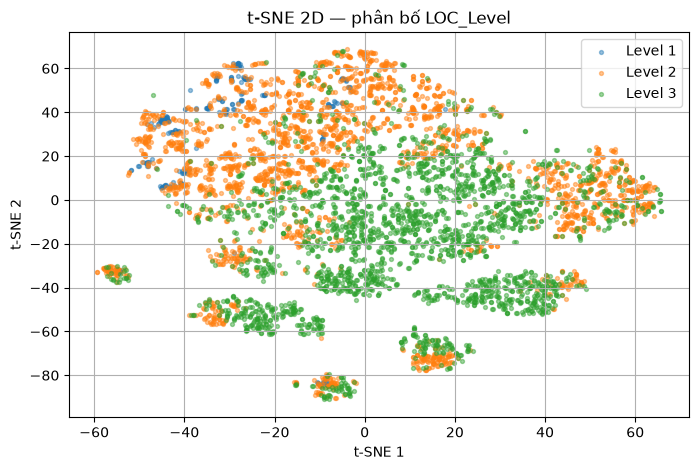

In [12]:
# 11. t-SNE visualization

tsne_sample_size = min(5000, len(df))
tsne_df = df.sample(n=tsne_sample_size, random_state=RANDOM_STATE)
X_tsne_base = tsne_df[feature_cols].fillna(X.median(numeric_only=True))
X_tsne_scaled = scaler.transform(X_tsne_base)

tsne = TSNE(
    n_components=2,
    perplexity=35,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE,
)
X_tsne = tsne.fit_transform(X_tsne_scaled)

plot_df = pd.DataFrame({
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
    "LOC_Level": tsne_df["LOC_Level"].values
})

plt.figure()
for level in sorted(plot_df["LOC_Level"].unique()):
    part = plot_df[plot_df["LOC_Level"] == level]
    plt.scatter(part["TSNE1"], part["TSNE2"], s=8, alpha=0.45, label=f"Level {level}")
plt.title("t-SNE 2D — phân bố LOC_Level")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.show()


,feature,importance
1,ADLs_IADLs__DiffWalk,0.162450
12,Clinical_Risk_Assessments__GenHlth,0.149115
20,Financial_Legal_General_Status__Age,0.142908
0,ADLs_IADLs__Age,0.131110
16,Mood_Behavioral_Health__Smoker,0.095635
10,Clinical_Risk_Assessments__Diabetes,0.061861
13,Clinical_Risk_Assessments__PhysHlth,0.053856
3,ADLs_IADLs__PhysHlth,0.052487
6,Clinical_Risk_Assessments__HeartDiseaseorAttack,0.028838
7,Clinical_Risk_Assessments__HighBP,0.025521


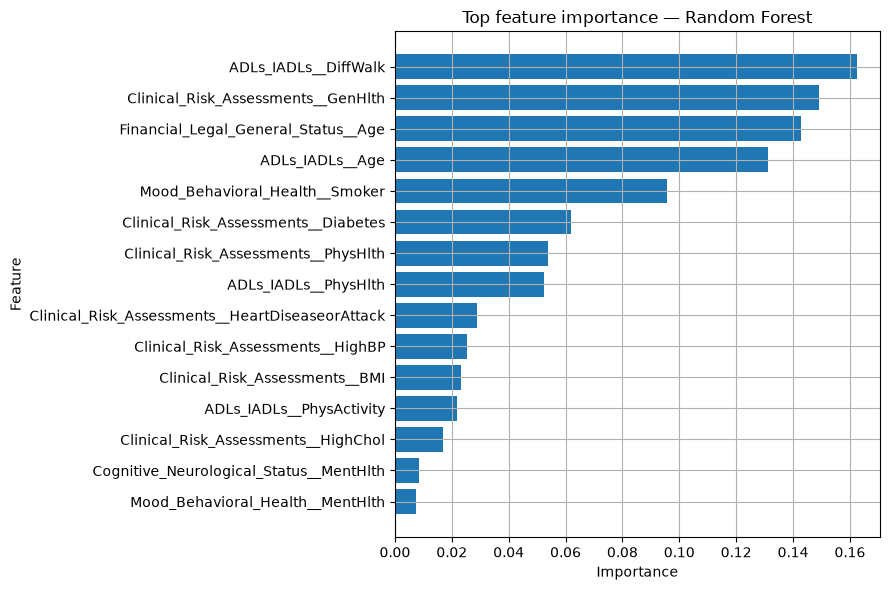

In [14]:
# 13. Feature importance

rf = RandomForestClassifier(
    n_estimators=250,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf.fit(X, y)

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

display(importance.head(20))

top_n = min(15, len(importance))
top_imp = importance.head(top_n).iloc[::-1]

plt.figure(figsize=(9, 6))
plt.barh(top_imp["feature"], top_imp["importance"])
plt.title("Top feature importance — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
